# Water Quality Mapping with PRISM L2A Reflectance

## Overview

The Portable Remote Imaging SpectroMeter ([PRISM](https://www.earthdata.nasa.gov/data/instruments/prism)) is a compact airborne pushbroom imaging spectrometer built by the NASA Jet Propulsion Laboratory (JPL) for studying coastal and inland waters. PRISM instrument covers spectral range from 350–1050 nm with with a 2.83 nm sampling per pixel, and a 0.88 mrad instantaneous field of view, with 608 cross-track pixels in a pushbroom configuration ([Mouroulis et al., 2014](https://doi.org/10.1364/AO.53.001363)).

In October-November 2023, [NASA Gulfstream III](https://www.earthdata.nasa.gov/data/platforms/air-based-platforms/g-iii) flew PRISM instrument for the **Biodiversity Survey of the Cape ([BioSCape](https://www.earthdata.nasa.gov/data/projects/bioscape))**, a NASA and South African National Space Agency (SANSA) campaign to study the terrestrial and aquatic biodiversity of South Africa's Greater Cape Floristic Region ([Cardoso et al., 2025](https://doi.org/10.1038/s44185-024-00071-5)).

In this tutorial, we use [PRISM Level 2A (L2A) surface reflectance](https://doi.org/10.3334/ORNLDAAC/2494) from BioSCape campaign, for two water quality case studies:

1. **A red tide in Gordon's Bay.** On 15 November 2023, PRISM imaged a bloom of *Noctiluca scintillans* in Gordon's Bay in the Western Cape province of South Africa. The bloom discolored the water and prompted [local news reports](https://www.dailyvoice.co.za/news/gordons-bay-red-tide-is-common-a5f8d660-4b58-4b41-8249-8566c1c6ce1a) warning residents to avoid swimming. We compare bloom and non-bloom spectra and map two chlorophyll indicators.
2. **Turbidity in Theewaterskloof Dam.** Theewaterskloof is the largest dam in the Western Cape Water Supply System, which supplies Cape Town and the surrounding region. After heavy rain in the winter and spring of 2023, the dam was full. On 26 November 2023, PRISM imaged its turbid water, and we map turbidity with a semi-empirical algorithm.

```{note}
This tutorial adapts two notebooks from the [2024 BioSCape Data Workshop](https://ornldaac.github.io/bioscape_workshop_sa/) (*[Exploring an Algal Bloom with Band Math](https://ornldaac.github.io/bioscape_workshop_sa/tutorials/prism_gordonsbay/prism_gordonsbay)* and *[Calculate Turbidity from PRISM data](https://ornldaac.github.io/bioscape_workshop_sa/tutorials/prism_turbidity/prism_turbidity.html)*). The workshop notebooks used a preliminary version of the data on the BioSCape cloud environment. This version uses the data published on NASA Earthdata.
```

### Dataset Used

| Dataset | DOI | Short Name |
|---|---|---|
| BioSCape: PRISM L2A Orthocorrected Surface Reflectance | [10.3334/ORNLDAAC/2494](https://doi.org/10.3334/ORNLDAAC/2494) | BioSCape_PRISM_L2A_RFL_2494 |

The L2A reflectance was retrieved from ([PRISM L1B radiance](https://doi.org/10.3334/ORNLDAAC/2493)) with an optimal estimation atmospheric correction, the same method used for correction of the EMIT datasets ([Thompson et al., 2020](https://earth.jpl.nasa.gov/emit/internal_resources/281)). The optimal estimation also produces a per-band **reflectance uncertainty** for every pixel. Please refer to the [user guide](https://data.ornldaac.earthdata.nasa.gov/public/bioscape/BioSCape_PRISM_L2A_RFL/comp/BioSCape_PRISM_L2A_RFL.pdf) for full dataset documentation.

### Learning Objectives

- Search for PRISM BioSCape L2A granules over a site with `earthaccess`, and open/stream selected files
- Compare reflectance spectra and their uncertainties
- Compute fluorescence line height (FLH), a chlorophyll index (NDCI), and turbidity
- Export the derived maps as Cloud Optimized GeoTIFFs

### Prerequisites

A free [NASA Earthdata Login](https://urs.earthdata.nasa.gov/) account is required. See the [prerequisites](../../docs/prerequisites.md) page for setup instructions.

## Import Libraries

In [1]:
import earthaccess
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray
import pyproj
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import warnings
warnings.filterwarnings('ignore')
# ESRI baselayers for visualizations
xyz = "https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}"
attr = "ESRI"

## Authentication

Use `earthaccess.login()` to authenticate with your NASA Earthdata Login credentials. If you have a `.netrc` file configured, login will complete without a prompt.

In [2]:
auth = earthaccess.login()

## Search for the Collection

We search NASA's Common Metadata Repository (CMR) for the collection by its DOI.

In [3]:
collections = earthaccess.search_datasets(doi="10.3334/ORNLDAAC/2494")

# print collection details
for c in collections:
    temporal = c.get_umm('TemporalExtents')[0]['RangeDateTimes'][0]
    size = c.get_umm('ArchiveAndDistributionInformation')['FileDistributionInformation'][0]
    print(f"Title      : {c.get_umm('EntryTitle')}")
    print(f"ShortName  : {c.get_umm('ShortName')}")
    print(f"Temporal   : {temporal['BeginningDateTime']} to {temporal['EndingDateTime']}")
    print(f"Total size : {size['TotalCollectionFileSize']} {size['TotalCollectionFileSizeUnit']}")

Title      : BioSCape: PRISM L2A Orthocorrected Surface Reflectance
ShortName  : BioSCape_PRISM_L2A_RFL_2494
Temporal   : 2023-10-17T00:00:00.000Z to 2023-11-26T23:59:59.999Z
Total size : 4.657 TB


## Search for the Granules

Each PRISM flight line is split into scenes, and each **granule** is one scene. A granule contains four files that share the naming convention `<flight line>_<scene>_L2A_OE_<version>_<product>`:

| Product | Format | Contents |
|---|---|---|
| `RFL_ORT` | NetCDF | Orthorectified surface reflectance, plus atmospheric and surface state variables |
| `UNC_ORT` | NetCDF | Reflectance uncertainty (one standard deviation) |
| `RFL_ORT_QL` | GeoTIFF | RGB quicklook |
| `.yaml` | YAML | Processing information |

The flight line identifier `prmYYYYMMDDthhmmss` gives the date and start time of the flight line in UTC.

We search a dataset using its shortname `BioSCape_PRISM_L2A_RFL_2494`.

In [4]:
short_name = 'BioSCape_PRISM_L2A_RFL_2494'
granules = earthaccess.search_data(short_name=short_name)
print(f"Granules found: {len(granules)}")

Granules found: 10202


We convert the granule metadata into a `geopandas` dataframe and plot the granule bounds.

In [5]:
def granule_details(g):
    """Returns granule metadata as a dictionary."""
    gname = g['umm']['GranuleUR']
    sp = gname.split('_')
    return {
        'file': gname,
        'flight_line': sp[0].removeprefix('prm'),
        'scene': sp[1],
        'data_links': g.data_links(),
        'start_time': pd.to_datetime(g['umm']['TemporalExtent']['RangeDateTime']['BeginningDateTime']),
        'size_mb': g.size(),
    }

# geopandas dataframe
gdf = gpd.GeoDataFrame(
    [granule_details(g) for g in granules],
    geometry=gpd.GeoSeries(granules, crs=4326),
)

# plot granule bounds, colored by flight line
gdf.explore(
    column='flight_line', tiles=xyz, attr=attr,
    style_kwds={"weight": 2, "fillOpacity": 0.5},
    tooltip=['file'], legend=False
)

### Export granule bounds for GIS (Optional)
We can optionally export the granule bounds into a GIS format such as `geojson`, `kml` or `shapefile` for further analysis in a desktop GIS.

In [6]:
# exporting to external files
gdf.to_file(f"{short_name}_granules.geojson", driver="GeoJSON")
gdf.to_file(f"{short_name}_granules.shp", driver="ESRI Shapefile")
gdf.to_file(f"{short_name}_granules.kml", driver="LIBKML")

### Search granules for the two sites
We search for granules over each site on the day it was imaged.

In [7]:
# bounding boxes: (west, south, east, north)
sites = {
    "Gordons Bay": {'bbox': (18.83, -34.18, 18.88, -34.14),
                     'date': '2023-11-15'},
    "Theewaterskloof Dam": {'bbox': (19.12, -34.08, 19.29, -33.99),
                            'date': '2023-11-26'},
}
rows = []
granules_all = []

# loop over each site and search granules that are over their
# bounding boxes and time period
for site, s in sites.items():
    results = earthaccess.search_data(
        short_name=short_name,
        bounding_box=s['bbox'],
        temporal=(s['date'], s['date']),
    )
    # granule metadata
    for g in results:
        rows.append({'site': site, 'granule': g['umm']['GranuleUR'],
                     'start_time': g['umm']['TemporalExtent']['RangeDateTime']['BeginningDateTime']})
        granules_all.append(g)

# creating a pandas dataframe
df = pd.DataFrame(rows)
df

,site,granule,start_time
0,Gordons Bay,prm20231115t092332_001_L2A_RFL_1,2023-11-15T09:24:28Z
1,Gordons Bay,prm20231115t092332_002_L2A_RFL_1,2023-11-15T09:24:43Z
2,Gordons Bay,prm20231115t092332_003_L2A_RFL_1,2023-11-15T09:24:58Z
3,Gordons Bay,prm20231115t092332_004_L2A_RFL_1,2023-11-15T09:25:14Z
4,Theewaterskloof Dam,prm20231126t080430_000_L2A_RFL_1,2023-11-26T08:05:18Z
5,Theewaterskloof Dam,prm20231126t080430_001_L2A_RFL_1,2023-11-26T08:05:29Z
6,Theewaterskloof Dam,prm20231126t080430_002_L2A_RFL_1,2023-11-26T08:05:41Z


Several flight lines crossed each site. We map the footprints of all matching scenes.

In [8]:
# converting to a geopandas dataframe
gdf = gpd.GeoDataFrame(df,
                       geometry=gpd.GeoSeries(granules_all, crs=4326))
# plt
gdf.explore(
    column='site', tiles=xyz, attr=attr,
    style_kwds={"weight": 2, "fillOpacity": 0.5},
    tooltip=['granule', 'start_time'],
)

We will use the scenes from the original workshop tutorials:

- Gordon's Bay: flight line `prm20231115t092332`, scene `003`, which covers the bloom in the bay
- Theewaterskloof Dam: flight line `prm20231126t080430`, scene `002`, which covers the northern part of the dam

In [9]:
scene_ids = {
    "Gordons Bay": 'prm20231115t092332_003',
    "Theewaterskloof Dam": 'prm20231126t080430_002',
}

# extracting DataGranules matching scene_ids
scenes = {site: [g for g in granules_all if g['umm']['GranuleUR'].startswith(sid)][0]
          for site, sid in scene_ids.items()}

Each granule has a public browse image, which we display below.

In [10]:
scenes["Gordons Bay"]

Collection: {'ShortName': 'BioSCape_PRISM_L2A_RFL_2494', 'Version': '1'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': 18.837511953683606, 'Latitude': -34.142848692965366}, {'Longitude': 18.836778980838815, 'Latitude': -34.171584232620454}, {'Longitude': 18.866531822380843, 'Latitude': -34.17210529960796}, {'Longitude': 18.867254732715786, 'Latitude': -34.14336920103793}, {'Longitude': 18.837511953683606, 'Latitude': -34.142848692965366}]}}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2023-11-15T09:24:58Z', 'EndingDateTime': '2023-11-15T09:25:14Z'}}
Size(MB): 490.4907341003418
Data: ['https://data.ornldaac.earthdata.nasa.gov/protected/bioscape/BioSCape_PRISM_L2A_RFL/data/prm20231115t092332_003_L2A_OE_3a030e80_RFL_ORT.nc', 'https://data.ornldaac.earthdata.nasa.gov/protected/bioscape/BioSCape_PRISM_L2A_RFL/data/prm20231115t092332_003_L2A_OE_3a030e80_UNC_ORT.nc', 'https://data.ornldaac.earthdata.nasa.gov/protected/bioscape/BioSCape_PRISM_L2A_RFL/data/prm20231115t092332_003_L2A_OE_3a030e80.yaml', 'https://data.ornldaac.earthdata.nasa.gov/protected/bioscape/BioSCape_PRISM_L2A_RFL/data/prm20231115t092332_003_L2A_OE_3a030e80_RFL_ORT_QL.tif']

In [11]:
scenes["Theewaterskloof Dam"]

Collection: {'ShortName': 'BioSCape_PRISM_L2A_RFL_2494', 'Version': '1'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': 19.172380841120862, 'Latitude': -34.00418345762143}, {'Longitude': 19.171978401926168, 'Latitude': -34.02295663230874}, {'Longitude': 19.211019711232204, 'Latitude': -34.02353094729995}, {'Longitude': 19.211413566771146, 'Latitude': -34.00475736926098}, {'Longitude': 19.172380841120862, 'Latitude': -34.00418345762143}]}}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2023-11-26T08:05:41Z', 'EndingDateTime': '2023-11-26T08:06:03Z'}}
Size(MB): 886.7934846878052
Data: ['https://data.ornldaac.earthdata.nasa.gov/protected/bioscape/BioSCape_PRISM_L2A_RFL/data/prm20231126t080430_002_L2A_OE_3a030e80_RFL_ORT.nc', 'https://data.ornldaac.earthdata.nasa.gov/protected/bioscape/BioSCape_PRISM_L2A_RFL/data/prm20231126t080430_002_L2A_OE_3a030e80_UNC_ORT.nc', 'https://data.ornldaac.earthdata.nasa.gov/protected/bioscape/BioSCape_PRISM_L2A_RFL/data/prm20231126t080430_002_L2A_OE_3a030e80.yaml', 'https://data.ornldaac.earthdata.nasa.gov/protected/bioscape/BioSCape_PRISM_L2A_RFL/data/prm20231126t080430_002_L2A_OE_3a030e80_RFL_ORT_QL.tif']

## Open the Granules

As we see above, each scene contains multiple granules. Here we only need the reflectance (`RFL_ORT.nc`) for both scenes, and the uncertainty (`UNC_ORT.nc`) for Gordon's Bay, so we pass those file links directly and open and stream the granule with `earthaccess.open()`.  

In [12]:
def data_urls(granule, suffix):
    """Returns the granule urls that ends with suffix."""
    return [u for u in granule.data_links() if u.endswith(suffix)][0]

# build granule urls list
urls = [
    data_urls(scenes["Gordons Bay"], 'RFL_ORT.nc'),
    data_urls(scenes["Gordons Bay"], 'UNC_ORT.nc'),
    data_urls(scenes["Theewaterskloof Dam"], 'RFL_ORT.nc'),
]
# open files
files = earthaccess.open(urls)
# file-like objects
gb_rfl_f, gb_unc_f, tw_rfl_f = files
# print
files

[<File-like object HTTPFileSystem, https://data.ornldaac.earthdata.nasa.gov/protected/bioscape/BioSCape_PRISM_L2A_RFL/data/prm20231115t092332_003_L2A_OE_3a030e80_RFL_ORT.nc>,
 <File-like object HTTPFileSystem, https://data.ornldaac.earthdata.nasa.gov/protected/bioscape/BioSCape_PRISM_L2A_RFL/data/prm20231115t092332_003_L2A_OE_3a030e80_UNC_ORT.nc>,
 <File-like object HTTPFileSystem, https://data.ornldaac.earthdata.nasa.gov/protected/bioscape/BioSCape_PRISM_L2A_RFL/data/prm20231126t080430_002_L2A_OE_3a030e80_RFL_ORT.nc>]

## Explore the File Structure

We open one of the reflectance file as an `xarray.DataTree` to view its groups.

In [13]:
dt = xr.open_datatree(gb_rfl_f)
dt

<xarray.DataTree>
Group: /
│   Dimensions:              (easting: 784, northing: 911)
│   Coordinates:
│     * easting              (easting) float64 6kB 3.006e+05 3.006e+05 ... 3.034e+05
│     * northing             (northing) float64 7kB 6.22e+06 6.22e+06 ... 6.217e+06
│   Data variables:
│       transverse_mercator  |S1 1B ...
│   Attributes: (12/23)
│       Conventions:                       CF-1.6
│       date_created:                      2026-03-17T18:10:39Z
│       summary:                           The Portable Remote Imaging Spectromet...
│       keywords:                          Imaging Spectroscopy, PRISM
│       sensor:                            Portable Remote Imaging Spectrometer
│       instrument:                        PRISM
│       ...                                ...
│       ncei_template_version:             NCEI_NetCDF_Grid_Template_v2.0
│       title:                             PRISM L2A Surface reflectance (flight ...
│       processing_level:                  L2A
│       time_coverage_start:               2023-11-15T09:24:58Z
│       time_coverage_end:                 2023-11-15T09:24:58Z
│       product_version:                   1
├── Group: /reflectance
│       Dimensions:      (wavelength: 246, northing: 911, easting: 784)
│       Coordinates:
│         * wavelength   (wavelength) float32 984B 350.6 353.4 ... 1.043e+03 1.046e+03
│       Data variables:
│           fwhm         (wavelength) float32 984B ...
│           reflectance  (wavelength, northing, easting) float32 703MB ...
└── Group: /state_variables
        Dimensions:                    (northing: 911, easting: 784)
        Data variables:
            aerosol_optical_thickness  (northing, easting) float32 3MB ...
            water_vapor                (northing, easting) float32 3MB ...
            surface_classification     (northing, easting) float32 3MB ...
            sky_glint                  (northing, easting) float32 3MB ...
            sun_glint                  (northing, easting) float32 3MB ...
            sky_glint_uncertainty      (northing, easting) float32 3MB ...
            sun_glint_uncertainty      (northing, easting) float32 3MB ...
        Attributes:
            description:  State solutions for the interpolated atmosphere and non-ref...

The reflectance file has three parts:

| Group | Variables | Description |
|---|---|---|
| `/` (root) | `easting`, `northing`, `transverse_mercator` | UTM coordinates of the pixel centers and the coordinate reference system (CRS) |
| `/reflectance` | `reflectance`, `wavelength`, `fwhm` | Surface reflectance with dimensions (`wavelength`, `northing`, `easting`) |
| `/state_variables` | `surface_classification`, `aerosol_optical_thickness`, `water_vapor`, `sun_glint`, `sky_glint`, ... | Atmospheric and surface properties retrieved with the reflectance. `surface_classification` is 0 for land and 1 for water. |

The uncertainty file (`UNC_ORT`) has the same layout, with an `/uncertainty` group in place of `/reflectance`. The nodata value is -9999, which `xarray` masks as no data or `NaN`.

### Function to open a PRISM L2A file
The function below opens a PRISM L2A file and returns each group as an `xarray.Dataset` with coordinates and the CRS attached. We will use this `open_prism_l2a` function throughout this notebook

In [14]:
def open_prism_l2a(f):
    """Open a PRISM L2A NetCDF file and 
    return its groups with coordinates and CRS."""
    dt = xr.open_datatree(f, engine='h5netcdf')
    # project crs
    crs = pyproj.CRS.from_wkt(dt['transverse_mercator'].attrs['crs_wkt'])
    groups = {}
    # loop over all variables
    for name in dt.children:
        # converting datatree to a xarray dataset
        ds = dt[name].to_dataset().rename({'easting': 'x',
                                           'northing': 'y'})
        groups[name] = ds.rio.write_crs(crs)
    return groups, crs

## Part 1: A Red Tide in Gordon's Bay

Now, let's open the reflectance and uncertainty file from Gordon's Bay and print its details.

In [15]:
# open RFL_ORT
gb, crs = open_prism_l2a(gb_rfl_f)
# reflectance
gb_rfl = gb['reflectance']['reflectance']
# state variables to get land/water mask
gb_state = gb['state_variables']
# uncertainty layer
gb_unc = open_prism_l2a(gb_unc_f)[0]['uncertainty']['uncertainty']
# file name
gb_name = gb_rfl_f.path.split("/")[-1]

print(f"{gb_name}")
print(f"CRS        : {crs.name}")
print(f"Pixel size : {float(gb_rfl.x.diff('x')[0]):.1f} m")
print(f"Shape      : {dict(gb_rfl.sizes)}")

prm20231115t092332_003_L2A_OE_3a030e80_RFL_ORT.nc
CRS        : WGS 84 / UTM zone 34S
Pixel size : 3.5 m
Shape      : {'wavelength': 246, 'y': 911, 'x': 784}


### True-Color Image and Surface Classification

We make a true-color image from the red (657 nm), green (546 nm), and blue (481 nm) bands. Water is much darker than land, so we calculate the contrast stretch from water pixels only. This brings out color differences in the water and saturates the land.

We first define two python functions - one for true color and another for contrast stretching. These functions we will use later throughout the notebook.

In [16]:
def stretch(band, lower=2, upper=98, mask=None):
    """Percentile contrast stretch to the 0-1 range."""
    ref = band if mask is None else band[mask]
    p_low, p_high = np.nanpercentile(ref, [lower, upper])
    return np.clip((band - p_low) / (p_high - p_low), 0, 1)

def true_color(rfl, mask=None):
    """True-color RGB array; pixels outside the image are white."""
    bands = rfl.sel(wavelength=[657, 546, 481], method='nearest').values
    rgb = np.dstack([stretch(b, mask=mask) for b in bands])
    rgb[np.isnan(bands[0])] = 1
    return rgb

We plot the true color RGB image with the contrast stretched for water, along with the land/water surface classification.

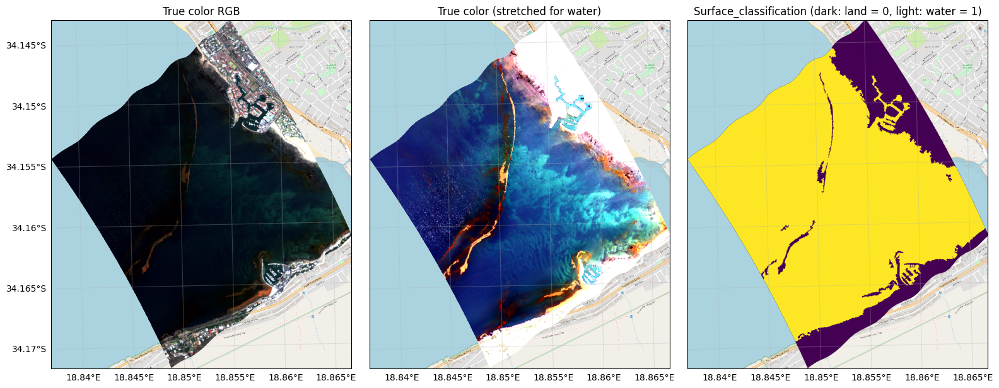

In [17]:
# water mask
gb_water = (gb_state['surface_classification'] == 1).values

# x, y bounds
gb_extent = [float(gb_rfl.x.min()), float(gb_rfl.x.max()),
             float(gb_rfl.y.min()), float(gb_rfl.y.max())]

# using native PRISM crs for tile background layer
proj = ccrs.epsg(crs.to_epsg())
tiles = cimgt.OSM()

# buffer of 0.5 km around image
pad = 500
map_extent = [gb_extent[0] - pad, gb_extent[1] + pad, 
              gb_extent[2] - pad, gb_extent[3] + pad]

# three columns subplots
fig, axes = plt.subplots(
    nrows=1, ncols=3, figsize=(16, 8), sharey=True,
    subplot_kw={'projection': proj}
)

titles = ['True color RGB',
         'True color (stretched for water)',
         'Surface_classification (dark: land = 0, light: water = 1)']

# add an alpha band for transparent pixels for nan
alpha = ~np.isnan(gb_rfl.values[0])
# 3 layers to plot
layers = [np.dstack([true_color(gb_rfl), 
                     alpha.astype(float)]),
          np.dstack([true_color(gb_rfl, mask=gb_water), 
                     alpha.astype(float)]),
          gb_state['surface_classification']]
# plotting over 3 axes
for i, (ax, title, layer) in enumerate(zip(axes, titles, layers)):
    ax.set_title(title)
    ax.set_extent(gb_extent, crs=proj)
    ax.add_image(tiles, 16)
    ax.imshow(layer, extent=gb_extent, origin='upper',
                   transform=proj, zorder=2, aspect='equal', )
    gl = ax.gridlines(draw_labels=True, alpha=0.3)
    gl.top_labels = gl.right_labels = False
    if i > 0:
        gl.left_labels = False
    ax.ticklabel_format(style='plain')
    ax.set_aspect('equal')
plt.tight_layout()
plt.show()

The bloom is visible as long, bright, cream-colored streaks with red-orange fringes running north to south through the bay. These are dense surface accumulations of *Noctiluca*. Notice that the classification marks the brightest streaks as land. Their reflectance in the near infrared is high, like land. Note that if we mask with `surface_classification`, the densest parts of the bloom will be removed.

## Compare Spectra with Uncertainty

We compare spectra at four locations - the core of a bloom streak, the red water at its edge, turquoise water, and dark water away from the bloom. The uncertainty file gives the one-standard-deviation uncertainty for each band, which we plot as a shaded band around each spectrum.

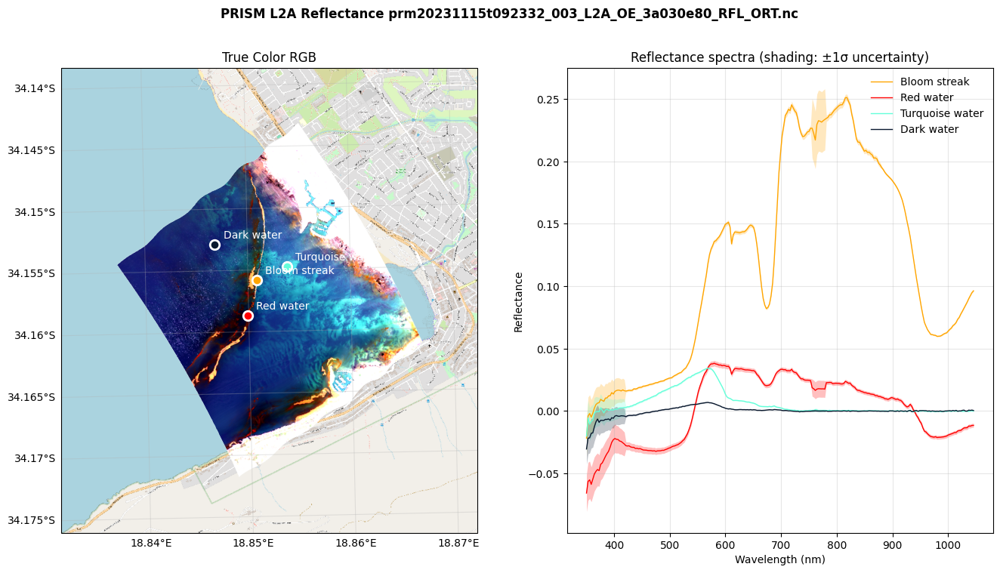

In [18]:
# locations (lat, lon) 
gb_points = {
    'Bloom streak': (-34.15582, 18.85087, 'orange'),
    'Red water': (-34.15867, 18.84992, 'red'),
    'Turquoise water': (-34.15479, 18.85384, '#64FFDA'),
    'Dark water': (-34.15286, 18.84684, '#0A192F'),
}

# transformer to convert from lat, lon to PRISM CRS (UTM)
transformer = pyproj.Transformer.from_crs("EPSG:4326", crs, 
                                          always_xy=True)
# wavelength
wl = gb_rfl['wavelength'].values

fig = plt.figure(figsize=(16, 8))

# First subplot
ax1 = fig.add_subplot(1, 2, 1, projection=proj)
ax1.set_extent(map_extent, crs=proj)
ax1.add_image(tiles, 16)
ax1.imshow(layers[1], extent=gb_extent, origin='upper', transform=proj, zorder=2)
gl = ax1.gridlines(draw_labels=True, alpha=0.3)
gl.top_labels = gl.right_labels = False

# Second subplot
ax2 = fig.add_subplot(1, 2, 2)

# loop over each of the four points
for (name, (lat, lon, color)) in gb_points.items():
    x, y = transformer.transform(lon, lat)
    ax1.plot(x, y, 'o', color=color, ms=9, mec='white', mew=2)
    ax1.annotate(name, (x, y), xytext=(8, 6), color='white',
                 textcoords='offset points', fontsize=10)
    spec = gb_rfl.sel(x=x, y=y, method='nearest')
    unc = gb_unc.sel(x=x, y=y, method='nearest')
    ax2.fill_between(wl, spec - unc, spec + unc,
                     color=color,alpha=0.25, lw=0)
    ax2.plot(wl, spec, color=color, lw=1, label=name)

plt.suptitle(f"PRISM L2A Reflectance {gb_name}",
             fontsize=12, fontweight='bold')
ax1.set_title('True Color RGB')
ax2.set_xlabel('Wavelength (nm)')
ax2.set_ylabel('Reflectance')
ax2.set_title("Reflectance spectra (shading: ±1σ uncertainty)")
ax2.legend(frameon=False)
ax2.grid(alpha=0.3)
plt.show()

The spectra differ clearly:

- The **bloom streak** is bright from ~560 nm into the near infrared (NIR), with a dip near 675 nm where chlorophyll-a absorbs light. Its shape resembles field spectra of dense *Noctiluca* blooms ([Mol et al., 2007](https://earsel.org/wp-content/uploads/2016/12/06_2_van-mol1.pdf)).
- The **red water** peaks near 580–600 nm and has a second peak near 700 nm. This 700 nm peak is typical of high-biomass water.
- The **turquoise** and **dark water** peak in the green (~570 nm) and fall close to zero in the NIR, as expected for water.
- The **red water** and **dark water** spectra are negative near near-UV and blue, and the red water spectrum is also negative beyond ~940 nm. This is typical of the red water across the bloom.

## Negative Reflectance

Water is dark, so small errors in the atmospheric correction can produce large relative errors in water reflectance. Before we apply an algorithm, we check how many water pixels have negative reflectance in each band.

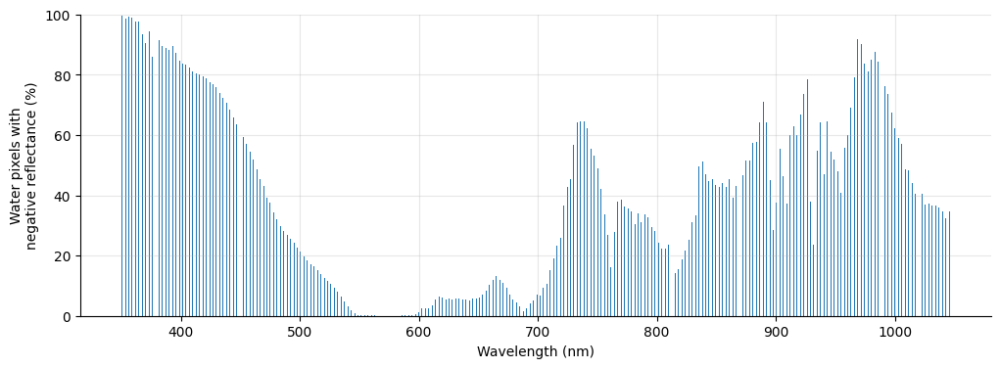

In [19]:
# water only reflectance
water_rfl = gb_rfl.where(gb_state['surface_classification'] == 1)
# percent negative pixels in water
negative_pct = (100 * (water_rfl < 0).sum(['x', 'y']) / 
                water_rfl.notnull().sum(['x', 'y']))

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(wl, negative_pct)
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Water pixels with\nnegative reflectance (%)')
ax.set_ylim(0, 100)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.show()

In the figure above,
- In the **NIR** (> 720 nm), water absorbs almost all light and its true reflectance is close to zero. Small random errors therefore make many pixels slightly negative. This is expected.
- In the **violet and blue** (412 and 443 nm), water reflectance should be clearly above zero, yet most water pixels are negative. This shows a systematic over-correction at short wavelengths over this water.
- In the **green, red, and red-edge** bands (550–710 nm), reflectance is almost always positive.

We use two of the **red and red-edge algorithms** that avoid the blue bands. They are also better suited to high-biomass, optically complex water like a red tide.

## Fluorescence Line Height (FLH)

Chlorophyll-a in phytoplankton re-emits some of the light it absorbs as fluorescence, with a peak near 681 nm. **Fluorescence line height** measures the height of that peak above a straight baseline drawn between two neighboring bands ([Letelier and Abbott, 1996](https://doi.org/10.1016/S0034-4257(96)00073-9)):

$$FLH = R_{rs}(\lambda_{fl}) - \left[R_{rs}(\lambda_{low}) + \frac{\lambda_{fl}-\lambda_{low}}{\lambda_{high}-\lambda_{low}} \times \left(R_{rs}(\lambda_{high}) - R_{rs}(\lambda_{low})\right)\right]$$

where $\lambda_{fl} \approx$ 681 nm is the fluorescence band, and $\lambda_{low} \approx$ 665 nm and $\lambda_{high} \approx$ 750 nm are the baseline bands.

FLH is usually calculated from water-leaving radiance ($R_{rs}$, in sr⁻¹), and not using remote sensing reflectance. The key difference is:
 - Water-leaving radiance is the radiance that exits the water and is detected by a satellite sensor after traveling through the atmosphere.
 - Remote sensing reflectance is the ratio of water-leaving radiance to downwelling irradiance just above the surface of the water, representing a normalized reflectance value.

The calculation of FLH is done directly from the radiance values because the fluorescence signal itself is an addition to the radiance at that wavelength, caused by chlorophyll fluorescence in the water column. It captures the deviation in radiance at the chlorophyll fluorescence wavelength (around 681 nm) compared to the baseline radiance, which is estimated by interpolating between radiance at surrounding bands.

We define two python functions for a baseline-subtracted peak heights, which we will use later.

In [20]:
def band(rfl, wavelength):
    """Selects the band nearest a wavelength. 
    Returns the band and its actual wavelength"""
    b = rfl.sel(wavelength=wavelength, method='nearest')
    return b.drop_vars('wavelength'), float(b['wavelength'])

def line_height(rfl, low, peak, high):
    """Height of the peak band above a linear baseline
    between the low and high bands."""
    r_low, w_low = band(rfl, low)
    r_peak, w_peak = band(rfl, peak)
    r_high, w_high = band(rfl, high)
    baseline = r_low + (w_peak - w_low) / (w_high - w_low) * (r_high - r_low)
    return r_peak - baseline

The L2A product is a reflectance factor, which for water is $\pi R_{rs}$, so we divide by $\pi$ to get $R_{rs}$. We then compute FLH for each points.

In [21]:
gb_rrs = gb_rfl / np.pi
flh = line_height(gb_rrs, 665, 681, 750)
flh.attrs = {'long_name': 'Fluorescence line height',
             'units': 'sr-1'}
# compute FLH for each points
for name, (lat, lon, color) in gb_points.items():
    x, y = transformer.transform(lon, lat)
    print(f"{name} FLH = {float(flh.sel(x=x, y=y, method='nearest')):.5f} sr-1")

Bloom streak FLH = -0.01011 sr-1
Red water FLH = -0.00069 sr-1
Turquoise water FLH = 0.00013 sr-1
Dark water FLH = 0.00021 sr-1


FLH is positive in the turquoise and dark water, but negative in the bloom streak and red water. 

## Normalized Difference Chlorophyll Index (NDCI)

FLH works best at low to moderate chlorophyll-a. In dense blooms, strong chlorophyll absorption near 675 nm and high particle scattering shift the red reflectance peak toward ~700 nm, which we saw in the red water spectrum, and FLH can become negative. The **Normalized Difference Chlorophyll Index** ([Mishra and Mishra, 2012](https://doi.org/10.1016/j.rse.2011.10.016)) uses that ~708 nm peak instead:

$$NDCI = \frac{R(708) - R(665)}{R(708) + R(665)}$$

NDCI increases with chlorophyll-a concentration and was designed for turbid, productive water. Because it is a normalized difference, it can be calculated directly from the reflectance factor.

In [22]:
def normalized_difference(rfl, w1, w2):
    # (R(w1) - R(w2)) / (R(w1) + R(w2))
    r1, _ = band(rfl, w1)
    r2, _ = band(rfl, w2)
    return (r1 - r2) / (r1 + r2)

ndci = normalized_difference(gb_rfl, 708, 665)
ndci.attrs = {'long_name': 'Normalized Difference Chlorophyll Index', 'units': '1'}

for name, (lat, lon, color) in gb_points.items():
    x, y = transformer.transform(lon, lat)
    print(f"{name:<16} NDCI = {float(ndci.sel(x=x, y=y, method='nearest')):.3f}")

Bloom streak     NDCI = 0.409
Red water        NDCI = 0.159
Turquoise water  NDCI = -0.455
Dark water       NDCI = 0.025


## Map FLH and NDCI

We map both indices side by side.

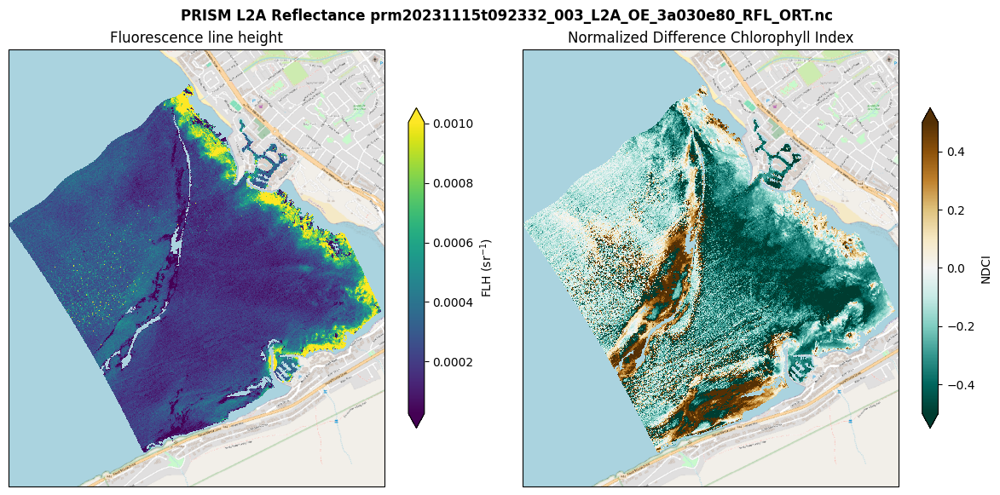

In [23]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6), sharey=True,
    subplot_kw={'projection': proj})

for ax in axes:
    ax.set_extent(gb_extent, crs=proj)
    ax.add_image(tiles, 16)


flh.where(gb_water).plot(ax=axes[0], cmap='viridis', robust=True, transform=proj, 
                         cbar_kwargs={'label': 'FLH (sr$^{-1}$)', 'shrink': 0.7})
axes[0].set_title('Fluorescence line height')

ndci.where(gb_water).plot(ax=axes[1], cmap='BrBG_r', vmin=-0.5, vmax=0.5, transform=proj, 
                          cbar_kwargs={'label': 'NDCI', 'shrink': 0.7})
axes[1].set_title('Normalized Difference Chlorophyll Index')
plt.suptitle(f"PRISM L2A Reflectance {gb_name}",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

The two indicators show different patterns:

- **FLH** is highest in a narrow band of nearshore water along the northeast shore, and lowest in and around the bloom streaks.
- **NDCI** is highest in the red water around the bloom streaks, and lowest in the turquoise water in the center of the bay.

NDCI highlights the dense bloom, where FLH is suppressed. Converting either index into chlorophyll-a concentration requires calibration with field measurements.

## Export Maps as a Cloud Optimized GeoTIFF

We stack FLH and NDCI into one dataset and export it as a Cloud Optimized GeoTIFF (COG), with one named band per variable. The helper function below also writes the CRS to the GeoTIFF.

In [24]:
def export_cog(ds, crs, path):
    """Write each variable of a dataset as a COG band"""
    out = ds.to_dataarray('band').rio.write_crs(crs)
    out.attrs['long_name'] = list(ds.data_vars)
    out.rio.write_nodata(np.nan).rio.to_raster(path, driver='COG')
    print(f"Saved: {path}")

# build xarray dataset
gb_out = xr.Dataset({'FLH': flh,
                     'NDCI': ndci}).where(gb_state['surface_classification'] == 1)

# export to cog
export_cog(gb_out, crs,
           f"{gb_name.replace('RFL_ORT', 'FLH_NDCI')}.tif")

Saved: prm20231115t092332_003_L2A_OE_3a030e80_FLH_NDCI.nc.tif


# Part 2: Turbidity in Theewaterskloof Dam

Turbidity measures the cloudiness of water caused by suspended particles such as silt, clay, organic matter, plankton, and other microscopic organisms. High turbidity reduces light penetration and aquatic plant growth, can harm fish and other aquatic organisms, and is an important measure of water quality.

## True-Color RGB Image and Water Spectra

We open the Theewaterskloof Dam scene and print summary details.

In [25]:
tw, tw_crs = open_prism_l2a(tw_rfl_f)
tw_rfl = tw['reflectance']['reflectance']
tw_state = tw['state_variables']
tw_water = (tw_state['surface_classification'] == 1).values
tw_extent = [float(tw_rfl.x.min()), float(tw_rfl.x.max()),
             float(tw_rfl.y.min()), float(tw_rfl.y.max())]
tw_granule = tw_rfl_f.path.split("/")[-1]
print(f"{tw_granule}")
print(f"CRS        : {tw_crs.name}")
print(f"Pixel size : {float(tw_rfl.x.diff('x')[0]):.1f} m")
print(f"Shape      : {dict(tw_rfl.sizes)}")

prm20231126t080430_002_L2A_OE_3a030e80_RFL_ORT.nc
CRS        : WGS 84 / UTM zone 34S
Pixel size : 2.6 m
Shape      : {'wavelength': 246, 'y': 801, 'x': 1387}


Now, we plot a true-color RGB image, and compare the spectra of three water pixels.

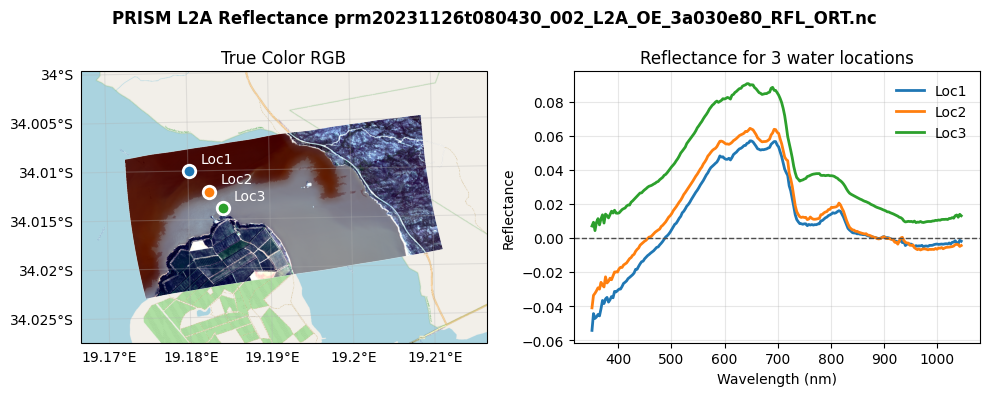

In [26]:
# water locations (lat, lon)
tw_points = {
    'Loc1': (-34.010002,19.180167),
    'Loc2': (-34.012156,19.182568),
    'Loc3': (-34.013833,19.184212),
}

# transformer to convert from lat, lon to UTM 34S
transformer = pyproj.Transformer.from_crs("EPSG:4326", tw_crs, 
                                          always_xy=True)

# add an alpha band for transparent pixels for nan
swath = ~np.isnan(tw_rfl.values[0])
rgba = np.dstack([true_color(tw_rfl), swath.astype(float)])

proj = ccrs.epsg(tw_crs.to_epsg())
tiles = cimgt.OSM()

# buffer of 1.5 km around image
pad = 500
map_extent = [tw_extent[0] - pad, tw_extent[1] + pad, 
              tw_extent[2] - pad, tw_extent[3] + pad]

fig = plt.figure(figsize=(10, 4))

# First subplot
ax1 = fig.add_subplot(1, 2, 1, projection=proj)
ax1.set_extent(map_extent, crs=proj)
ax1.add_image(tiles, 16)
ax1.imshow(rgba, extent=tw_extent, origin='upper',
           transform=proj, zorder=2)
gl = ax1.gridlines(draw_labels=True, alpha=0.3)
gl.top_labels = gl.right_labels = False

# Second subplot
ax2 = fig.add_subplot(1, 2, 2)

for (name, (lat, lon)) in tw_points.items():
    x, y = transformer.transform(lon, lat)
    ax1.plot(x, y, 'o', ms=9, mec='white', mew=2)
    ax1.annotate(name, (x, y), xytext=(8, 6), color='white',
                 textcoords='offset points', fontsize=10)
    ax2.plot(tw_rfl['wavelength'],
             tw_rfl.sel(x=x, y=y, method='nearest'),
             lw=2, label=name)

plt.suptitle(f"PRISM L2A Reflectance {tw_granule}",
             fontsize=12, fontweight='bold')
ax1.set_title('True Color RGB')
ax2.axhline(0, color='0.3', linestyle="--", lw=1)
ax2.set_xlabel('Wavelength (nm)')
ax2.set_ylabel('Reflectance')
ax2.set_title('Reflectance for 3 water locations')
ax2.legend(frameon=False)
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The dam water reflectance rises from the blue to a broad maximum between ~600 and ~700 nm, then drops sharply after 710 nm. A small peak near 810 nm is typical of water with high suspended sediment. As with Gordon's Bay, the blue reflectance is negative, but turbidity algorithms use the red and NIR bands.

## Calculate Turbidity

We use the single-band, semi-empirical turbidity algorithm of [Nechad et al. (2010)](https://doi.org/10.1016/j.rse.2009.11.022), with the coefficients of [Dogliotti et al. (2015)](https://doi.org/10.1016/j.rse.2014.09.020):

$$T = \frac{A \, \rho_w}{1 - \rho_w / C}$$

where $T$ is turbidity in Formazin Nephelometric Units (FNU), $\rho_w$ is the water leaving reflectance, and $A$ and $C$ are calibration coefficients for a given wavelength:

| Wavelength | A | C |
|---|---|---|
| 645 nm (red) | 228.1 | 0.1641 |
| 859 nm (NIR) | 3078.9 | 0.2112 |

The red band is sensitive in low-to-moderate turbidity but saturates in very turbid water. The NIR band is used in very turbid water. Dogliotti switch between them based on $\rho_w$ at 645nm, the red algorithm below 0.05, the NIR algorithm above 0.07, and a linear blend in between.

In [27]:
rho_645 = band(tw_rfl, 645)[0]
print(f"Median rho_w(645): {float(rho_645.median()):.4f}")

Median rho_w(645): 0.0678


We compute Nechad's turbidity for red and NIR bands as well as Dogliotti's blended turbidity over water as $\rho_w$.

In [28]:
def nechad_turbidity(rho_w, A, C):
    # Nechad et al. single-band turbidity (FNU)
    return A * rho_w / (1 - rho_w / C)

def dogliotti_turbidity(rfl, lower=0.05, upper=0.07):
    # Dogliotti et al. turbidity from the red (645 nm) and NIR (859 nm) bands
    red, _ = band(rfl, 645)
    nir, _ = band(rfl, 859)
    t_red = nechad_turbidity(red, 228.1, 0.1641)
    t_nir = nechad_turbidity(nir, 3078.9, 0.2112)
    # blending weight: 0 at rho_w(645) <= lower, 1 at rho_w(645) >= upper
    w = ((red - lower) / (upper - lower)).clip(0, 1)
    t_blend = (1 - w) * t_red + w * t_nir
    return xr.Dataset({'T_red': t_red, 'T_nir': t_nir, 'T_blended': t_blend})

turb = dogliotti_turbidity(tw_rfl)
turb.median().to_pandas().rename('median turbidity (FNU)').to_frame()

,median turbidity (FNU)
T_red,25.609760
T_nir,54.068859
T_blended,16.231115


## Compare the Turbidity Maps

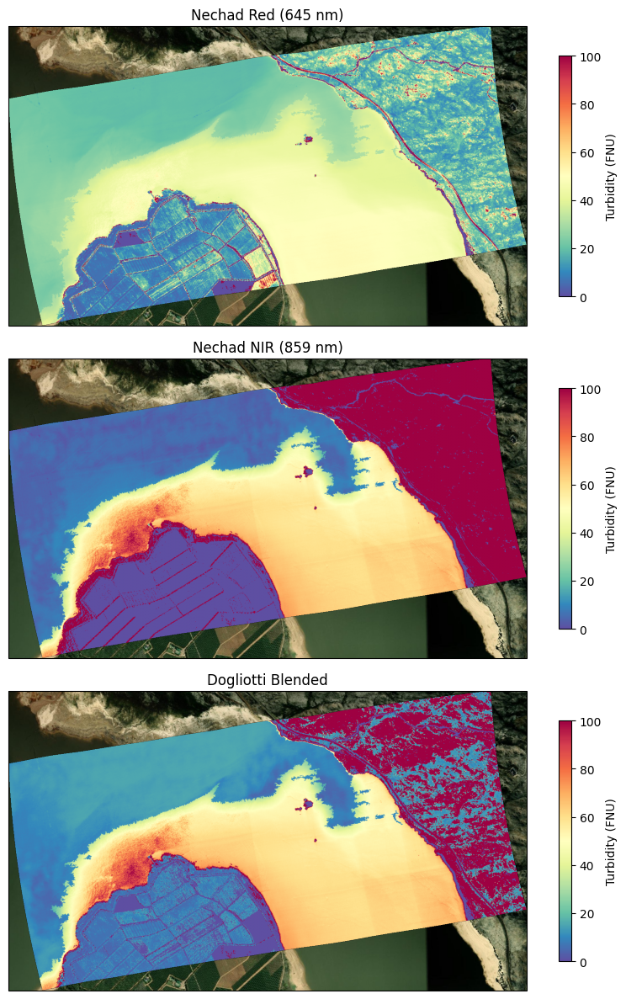

In [29]:
titles = {'T_red': 'Nechad Red (645 nm)',
          'T_nir': 'Nechad NIR (859 nm)',
          'T_blended': 'Dogliotti Blended'}

# UTM projection
proj = ccrs.epsg(tw_crs.to_epsg())
tiles = cimgt.GoogleTiles(url=xyz)

fig, axes = plt.subplots(
    nrows=3, ncols=1, figsize=(8, 12), 
    subplot_kw={'projection': proj}
)
for ax, (var, title) in zip(axes, titles.items()):
    ax.set_extent(tw_extent, crs=proj)
    ax.add_image(tiles, 16)
    im = ax.imshow(turb[var], cmap='Spectral_r', vmin=0, vmax=100, 
              extent=tw_extent, origin='upper', transform=proj, zorder=2)
    cbar = fig.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Turbidity (FNU)')
    ax.set_title(title)
    ax.set_xlabel('Easting (m)')
    ax.set_ylabel('Northing (m)')
    ax.ticklabel_format(style='plain')
    ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## Export the Turbidity Maps

We export the three turbidity estimates as a three-band COG. The GeoTIFFs can be opened in GIS software such as QGIS for further analysis.

In [30]:
tw_tif = f"{tw_granule.replace('RFL_ORT', 'turbidity')}.tif"
export_cog(turb, tw_crs, tw_tif)

Saved: prm20231126t080430_002_L2A_OE_3a030e80_turbidity.nc.tif
